# 02 - VECM and Johansen Cointegration Test: Complete Solution

This is the **complete solution** for the VECM/Johansen notebook.
All exercises are fully resolved with outputs saved.

---

## Topics covered

1. Cointegration and the VECM representation
2. Johansen trace and max-eigenvalue tests
3. VECM estimation (alpha, beta, Gamma)
4. Error correction terms interpretation
5. **Exercise 1: US Macro cointegration** (SOLVED)
6. **Exercise 2: Deterministic specification comparison** (SOLVED)

---

### From VAR to VECM

$$\Delta Y_t = \Pi Y_{t-1} + \Gamma_1 \Delta Y_{t-1} + \cdots + \Gamma_{p-1} \Delta Y_{t-p+1} + c + u_t$$

where $\Pi = \alpha \beta'$ has rank $r < K$ (the cointegration rank).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
import os

from chronobox import VECM

sys.path.insert(0, os.path.join("..", "utils"))
from plot_helpers import plot_multivariate_series

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
np.set_printoptions(precision=4, suppress=True)

print("All imports loaded successfully.")

All imports loaded successfully.


## 1. Loading the Canadian macro dataset

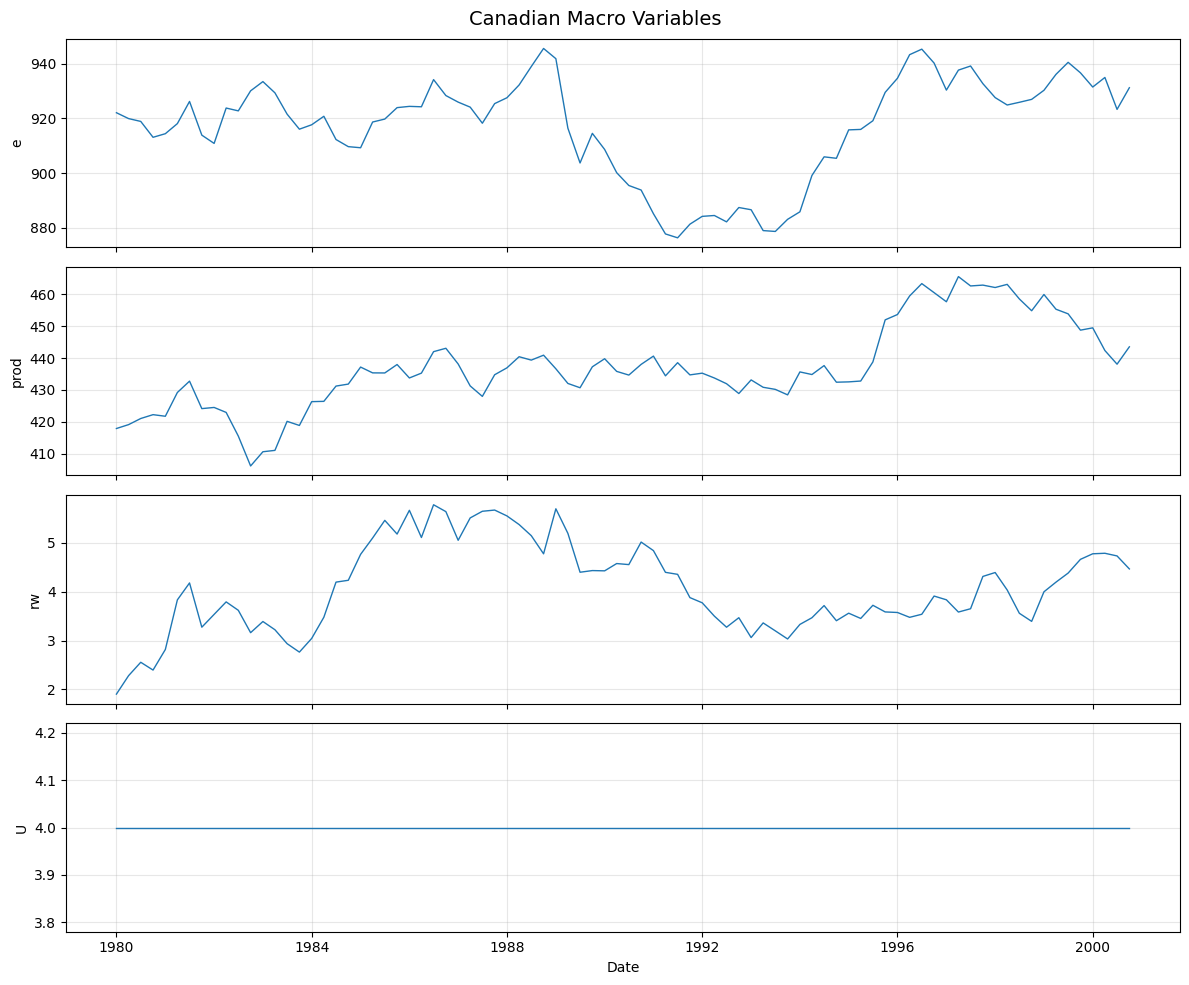

Shape: (84, 4) (84 obs, 4 variables)


In [2]:
data_path = os.path.join("..", "data", "canada_macro.csv")
df = pd.read_csv(data_path)
var_names = ["e", "prod", "rw", "U"]
endog = df[var_names].values

fig = plot_multivariate_series(df, date_col="date", title="Canadian Macro Variables")
plt.show()

print(f"Shape: {endog.shape} ({endog.shape[0]} obs, {endog.shape[1]} variables)")

## 2. Johansen cointegration test

- **Trace statistic**: $H_0: \text{rank}(\Pi) \leq r$ vs $H_1: \text{rank}(\Pi) > r$
- **Max-eigenvalue statistic**: $H_0: \text{rank}(\Pi) = r$ vs $H_1: \text{rank}(\Pi) = r + 1$

In [3]:
vecm = VECM(lags=2, deterministic="ci")
johansen = vecm.johansen_test(endog)

print(johansen.summary())

  Johansen Cointegration Test
  Deterministic: ci
  Observations: 82

  Trace Test
------------------------------------------------------------------------------
  H0: r<=      Eigenvalue   Trace Stat     90% CV     95% CV     99% CV
  --------------------------------------------------------------------------
  0                0.1050      14.9529      49.65      53.12      60.16
  1                0.0392       5.8548      32.00      34.91      41.07
  2                0.0309       2.5727      17.85      19.96      24.60
  3                0.0000      -0.0000       7.52       9.24      12.97
  Selected rank (trace, 5%): 0

  Max-Eigenvalue Test
------------------------------------------------------------------------------
  H0: r=       Eigenvalue Max-Eig Stat     90% CV     95% CV     99% CV
  --------------------------------------------------------------------------
  0                0.1050       9.0981      25.56      28.14      33.24
  1                0.0392       3.2821      19.

In [4]:
K = endog.shape[1]
print("Trace Test:")
print(f"{'r':>4s}  {'Trace Stat':>12s}  {'90%':>10s}  {'95%':>10s}  {'99%':>10s}  {'Decision':>10s}")
print("-" * 70)
for r in range(K):
    stat = johansen.trace_stat[r]
    c90, c95, c99 = johansen.trace_crit[r]
    reject = "Reject" if stat > c95 else "Fail"
    print(f"{r:>4d}  {stat:>12.4f}  {c90:>10.4f}  {c95:>10.4f}  {c99:>10.4f}  {reject:>10s}")

print(f"\nTrace test suggests rank = {johansen.rank_trace}")

Trace Test:
   r    Trace Stat         90%         95%         99%    Decision
----------------------------------------------------------------------
   0       14.9529     49.6500     53.1200     60.1600        Fail
   1        5.8548     32.0000     34.9100     41.0700        Fail
   2        2.5727     17.8500     19.9600     24.6000        Fail
   3       -0.0000      7.5200      9.2400     12.9700        Fail

Trace test suggests rank = 0


In [5]:
print("Max-Eigenvalue Test:")
print(f"{'r':>4s}  {'Max-Eig Stat':>14s}  {'90%':>10s}  {'95%':>10s}  {'99%':>10s}  {'Decision':>10s}")
print("-" * 72)
for r in range(K):
    stat = johansen.max_eig_stat[r]
    c90, c95, c99 = johansen.max_eig_crit[r]
    reject = "Reject" if stat > c95 else "Fail"
    print(f"{r:>4d}  {stat:>14.4f}  {c90:>10.4f}  {c95:>10.4f}  {c99:>10.4f}  {reject:>10s}")

print(f"\nMax-eigenvalue test suggests rank = {johansen.rank_maxeig}")

Max-Eigenvalue Test:
   r    Max-Eig Stat         90%         95%         99%    Decision
------------------------------------------------------------------------
   0          9.0981     25.5600     28.1400     33.2400        Fail
   1          3.2821     19.7700     22.0000     26.8100        Fail
   2          2.5727     13.7500     15.6700     20.2000        Fail
   3         -0.0000      7.5200      9.2400     12.9700        Fail

Max-eigenvalue test suggests rank = 0


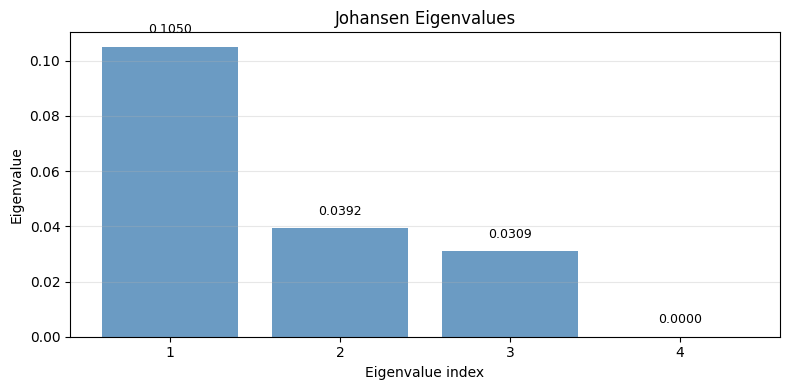

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, K + 1), johansen.eigenvalues, color="steelblue", alpha=0.8)
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel("Eigenvalue")
ax.set_title("Johansen Eigenvalues")
ax.set_xticks(range(1, K + 1))
ax.grid(True, alpha=0.3, axis="y")

for i, ev in enumerate(johansen.eigenvalues):
    ax.text(i + 1, ev + 0.005, f"{ev:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 3. Fitting the VECM

In [7]:
r = johansen.rank_trace
if r == 0:
    print("Trace test found rank=0. Using rank=1 for illustrative purposes.")
    r = 1

print(f"Fitting VECM with cointegration rank r = {r}")

vecm_model = VECM(lags=2, coint_rank=r, deterministic="ci")
vecm_results = vecm_model.fit(endog, names=var_names)

print(vecm_results.summary())

Trace test found rank=0. Using rank=1 for illustrative purposes.
Fitting VECM with cointegration rank r = 1
  VECM Estimation Results (Johansen)
  No. of equations:      4
  Lags in levels (VAR):  2
  Lags in differences:   1
  Cointegration rank:    1
  Deterministic:         ci
  Observations (used):   82

------------------------------------------------------------------------------
  Alpha (Loading Matrix)
------------------------------------------------------------------------------
           EC1
  e             0.004981
  prod          0.025615
  rw            0.002987
  U             0.000000

------------------------------------------------------------------------------
  Beta (Cointegrating Vectors)
------------------------------------------------------------------------------
           CV1
  e             1.000000
  prod         -0.817975
  rw          -35.108392
  U           -95.542509
  det_1       -23.885627

-------------------------------------------------------------

## 4. Interpreting Alpha and Beta

In [8]:
alpha_df = pd.DataFrame(
    vecm_results.alpha,
    index=var_names,
    columns=[f"EC{i+1}" for i in range(vecm_results.coint_rank)]
)
print("Alpha (speed of adjustment):")
print(alpha_df.round(4))

print("\n--- Interpretation ---")
for i, name in enumerate(var_names):
    for j in range(vecm_results.coint_rank):
        a = vecm_results.alpha[i, j]
        direction = "error-correcting" if a < 0 else "destabilizing"
        print(f"  {name} responds to EC{j+1}: alpha = {a:.4f} ({direction})")

Alpha (speed of adjustment):
         EC1
e     0.0050
prod  0.0256
rw    0.0030
U     0.0000

--- Interpretation ---
  e responds to EC1: alpha = 0.0050 (destabilizing)
  prod responds to EC1: alpha = 0.0256 (destabilizing)
  rw responds to EC1: alpha = 0.0030 (destabilizing)
  U responds to EC1: alpha = 0.0000 (destabilizing)


In [9]:
beta_df = pd.DataFrame(
    vecm_results.beta,
    columns=[f"EC{i+1}" for i in range(vecm_results.coint_rank)]
)
beta_labels = var_names.copy()
if vecm_results.beta.shape[0] > len(var_names):
    for d in range(vecm_results.beta.shape[0] - len(var_names)):
        beta_labels.append(f"det_{d}")
beta_df.index = beta_labels

print("Beta (cointegrating vectors):")
print(beta_df.round(4))

print("\nLong-run equilibrium relation(s):")
for j in range(vecm_results.coint_rank):
    terms = []
    for i, name in enumerate(var_names):
        coef = vecm_results.beta[i, j]
        if abs(coef) > 1e-10:
            terms.append(f"{coef:+.4f}*{name}")
    print(f"  EC{j+1}: {' '.join(terms)} = 0")

Beta (cointegrating vectors):
           EC1
e       1.0000
prod   -0.8180
rw    -35.1084
U     -95.5425
det_0 -23.8856

Long-run equilibrium relation(s):
  EC1: +1.0000*e -0.8180*prod -35.1084*rw -95.5425*U = 0


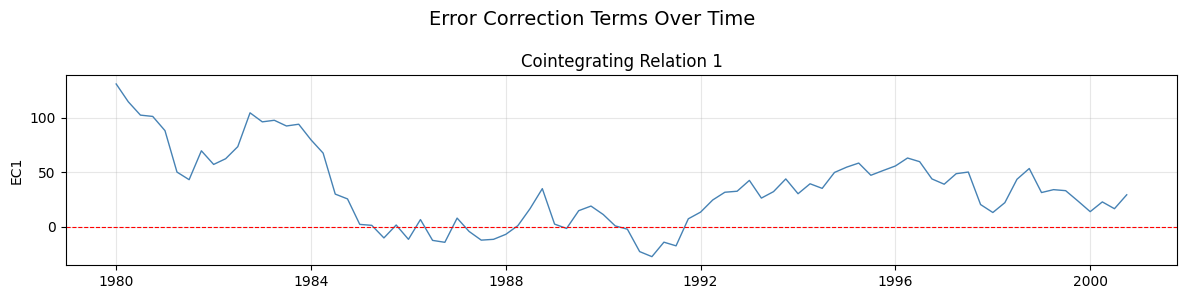

In [10]:
# Error correction terms over time
beta_vars = vecm_results.beta[:len(var_names), :]
ec_terms = endog @ beta_vars

fig, axes = plt.subplots(vecm_results.coint_rank, 1, figsize=(12, 3 * vecm_results.coint_rank),
                         squeeze=False)
fig.suptitle("Error Correction Terms Over Time", fontsize=14)

dates = pd.to_datetime(df["date"])
for j in range(vecm_results.coint_rank):
    ax = axes[j, 0]
    ax.plot(dates, ec_terms[:, j], color="steelblue", linewidth=1.0)
    ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
    ax.set_ylabel(f"EC{j+1}")
    ax.set_title(f"Cointegrating Relation {j+1}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
pi = vecm_results.pi
print("Long-run matrix Pi = alpha * beta':")
print(pd.DataFrame(pi, index=var_names, columns=var_names).round(4))

print(f"\nRank of Pi: {vecm_results.coint_rank}")
print(f"Number of common stochastic trends: {len(var_names) - vecm_results.coint_rank}")

Long-run matrix Pi = alpha * beta':
           e    prod      rw       U
e     0.0050 -0.0041 -0.1749 -0.4759
prod  0.0256 -0.0210 -0.8993 -2.4473
rw    0.0030 -0.0024 -0.1049 -0.2854
U     0.0000  0.0000  0.0000  0.0000

Rank of Pi: 1
Number of common stochastic trends: 3


In [12]:
for i, gamma in enumerate(vecm_results.gamma):
    print(f"\nGamma_{i+1} (short-run dynamics, lagged difference {i+1}):")
    print(pd.DataFrame(gamma, index=var_names, columns=var_names).round(4))


Gamma_1 (short-run dynamics, lagged difference 1):
           e    prod      rw    U
e     0.1760  0.1995 -4.5295  0.0
prod -0.0542  0.0437 -0.1806  0.0
rw    0.0078 -0.0021 -0.0364  0.0
U     0.0000  0.0000  0.0000  0.0


---

## Exercise 1: Cointegration in US Macro data (SOLUTION)

1. Run Johansen test with `lags=4` and `deterministic="ci"`
2. Compare trace vs max-eigenvalue results
3. Estimate VECM with the rank found
4. Interpret the cointegrating vectors ($\beta$)
5. Which variables adjust fastest to equilibrium?
6. **Save results to outputs/johansen_results.json**

US Macro data: 200 obs, 4 variables
Period: 1975-01-01 to 2024-10-01


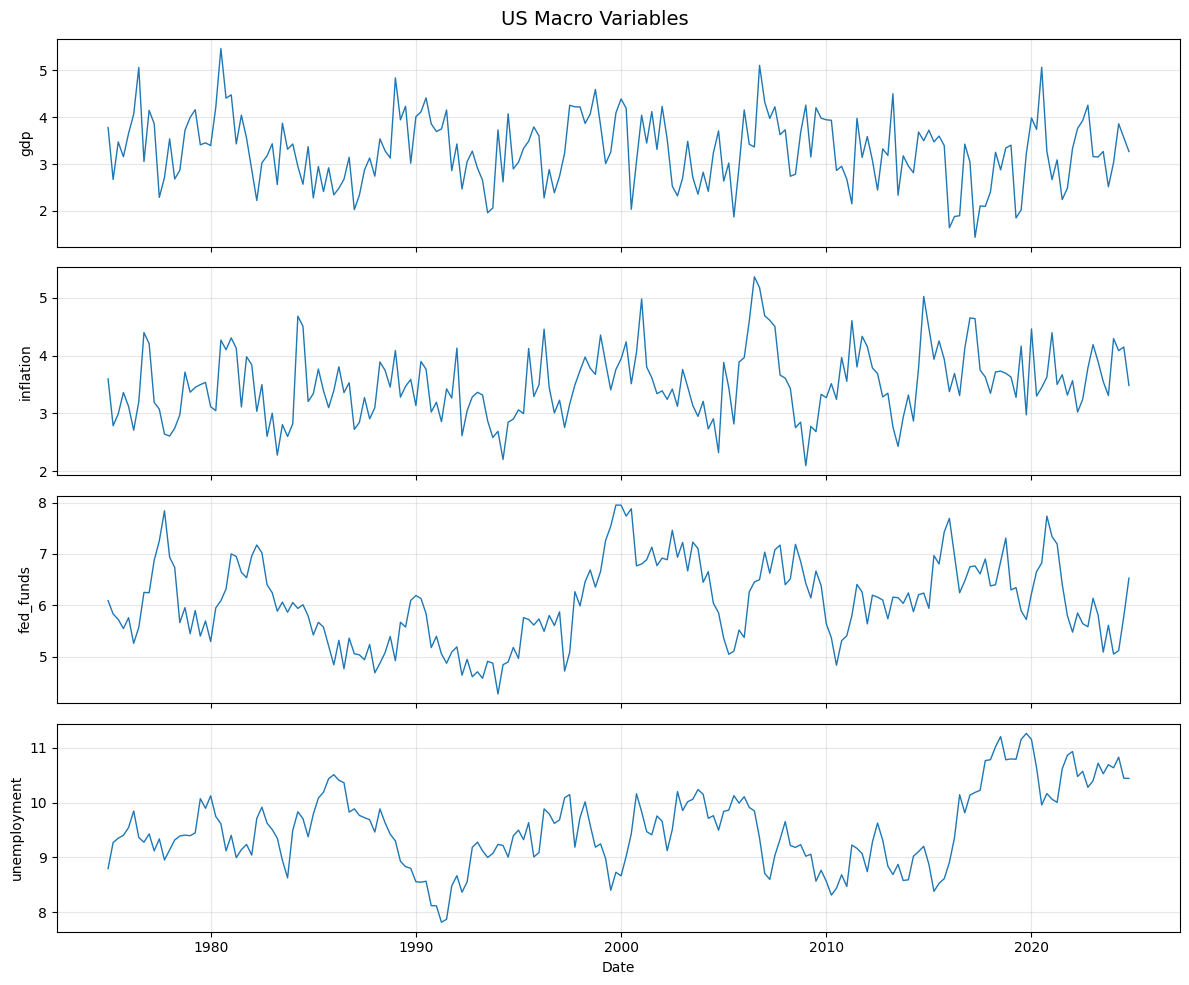

In [13]:
# Step 1: Load US data and run Johansen test
us_df = pd.read_csv(os.path.join("..", "data", "us_macro_quarterly.csv"))
us_names = ["gdp", "inflation", "fed_funds", "unemployment"]
us_endog = us_df[us_names].values

print(f"US Macro data: {us_endog.shape[0]} obs, {us_endog.shape[1]} variables")
print(f"Period: {us_df['date'].iloc[0]} to {us_df['date'].iloc[-1]}")

fig = plot_multivariate_series(us_df, date_col="date", title="US Macro Variables")
plt.show()

In [14]:
# Johansen test on US data
us_vecm = VECM(lags=4, deterministic="ci")
us_johansen = us_vecm.johansen_test(us_endog)

print(us_johansen.summary())

  Johansen Cointegration Test
  Deterministic: ci
  Observations: 196

  Trace Test
------------------------------------------------------------------------------
  H0: r<=      Eigenvalue   Trace Stat     90% CV     95% CV     99% CV
  --------------------------------------------------------------------------
  0                0.1903     100.2430      49.65      53.12      60.16 **
  1                0.1678      58.8718      32.00      34.91      41.07 **
  2                0.0851      22.8620      17.85      19.96      24.60 **
  3                0.0274       5.4373       7.52       9.24      12.97
  Selected rank (trace, 5%): 3

  Max-Eigenvalue Test
------------------------------------------------------------------------------
  H0: r=       Eigenvalue Max-Eig Stat     90% CV     95% CV     99% CV
  --------------------------------------------------------------------------
  0                0.1903      41.3712      25.56      28.14      33.24 **
  1                0.1678      36.

In [15]:
# Step 2: Detailed comparison trace vs max-eigenvalue
K_us = us_endog.shape[1]

print("Trace Test (US Macro):")
print(f"{'r':>4s}  {'Trace Stat':>12s}  {'95% CV':>10s}  {'Decision':>10s}")
print("-" * 45)
for r in range(K_us):
    stat = us_johansen.trace_stat[r]
    c95 = us_johansen.trace_crit[r][1]
    reject = "Reject H0" if stat > c95 else "Fail"
    print(f"{r:>4d}  {stat:>12.4f}  {c95:>10.4f}  {reject:>10s}")

print(f"\nTrace test rank: {us_johansen.rank_trace}")

print("\nMax-Eigenvalue Test (US Macro):")
print(f"{'r':>4s}  {'Max-Eig Stat':>14s}  {'95% CV':>10s}  {'Decision':>10s}")
print("-" * 47)
for r in range(K_us):
    stat = us_johansen.max_eig_stat[r]
    c95 = us_johansen.max_eig_crit[r][1]
    reject = "Reject H0" if stat > c95 else "Fail"
    print(f"{r:>4d}  {stat:>14.4f}  {c95:>10.4f}  {reject:>10s}")

print(f"\nMax-eigenvalue test rank: {us_johansen.rank_maxeig}")

print(f"\n--- Comparison ---")
print(f"Trace rank:          {us_johansen.rank_trace}")
print(f"Max-eigenvalue rank: {us_johansen.rank_maxeig}")
if us_johansen.rank_trace == us_johansen.rank_maxeig:
    print("Both tests agree on the cointegration rank.")
else:
    print("Tests disagree. Trace test is generally preferred in small samples.")

Trace Test (US Macro):
   r    Trace Stat      95% CV    Decision
---------------------------------------------
   0      100.2430     53.1200   Reject H0
   1       58.8718     34.9100   Reject H0
   2       22.8620     19.9600   Reject H0
   3        5.4373      9.2400        Fail

Trace test rank: 3

Max-Eigenvalue Test (US Macro):
   r    Max-Eig Stat      95% CV    Decision
-----------------------------------------------
   0         41.3712     28.1400   Reject H0
   1         36.0097     22.0000   Reject H0
   2         17.4247     15.6700   Reject H0
   3          5.4373      9.2400        Fail

Max-eigenvalue test rank: 3

--- Comparison ---
Trace rank:          3
Max-eigenvalue rank: 3
Both tests agree on the cointegration rank.


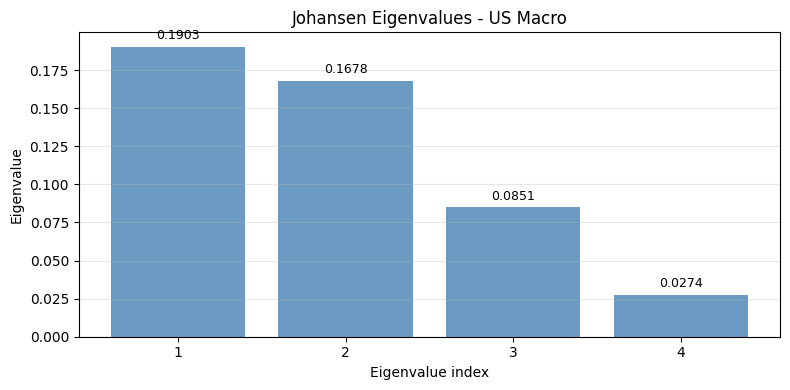

In [16]:
# Plot US eigenvalues
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, K_us + 1), us_johansen.eigenvalues, color="steelblue", alpha=0.8)
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel("Eigenvalue")
ax.set_title("Johansen Eigenvalues - US Macro")
ax.set_xticks(range(1, K_us + 1))
ax.grid(True, alpha=0.3, axis="y")
for i, ev in enumerate(us_johansen.eigenvalues):
    ax.text(i + 1, ev + 0.005, f"{ev:.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [17]:
# Step 3: Estimate VECM
r_us = us_johansen.rank_trace
# Ensure rank is at least 1 for a meaningful VECM
if r_us == 0:
    print("Trace test found rank=0. Using rank=1 for illustrative purposes.")
    r_us = 1

print(f"Fitting VECM with rank r = {r_us}")

us_vecm_fit = VECM(lags=4, coint_rank=r_us, deterministic="ci")
us_vecm_results = us_vecm_fit.fit(us_endog, names=us_names)

print(us_vecm_results.summary())

Fitting VECM with rank r = 3
  VECM Estimation Results (Johansen)
  No. of equations:      4
  Lags in levels (VAR):  4
  Lags in differences:   3
  Cointegration rank:    3
  Deterministic:         ci
  Observations (used):   196

------------------------------------------------------------------------------
  Alpha (Loading Matrix)
------------------------------------------------------------------------------
           EC1         EC2         EC3
  gdp          -0.286476   -0.135433   -0.018651
  inflation     0.291624   -0.138562   -0.008266
  fed_funds     0.022809    0.153337   -0.008124
  unemployment   -0.091683   -0.057493    0.004913

------------------------------------------------------------------------------
  Beta (Cointegrating Vectors)
------------------------------------------------------------------------------
           CV1         CV2         CV3
  gdp           1.000000    1.000000    1.000000
  inflation    -0.747413    1.577188    3.424810
  fed_funds    -0.001

In [18]:
# Step 4: Interpret beta (cointegrating vectors)
us_alpha_df = pd.DataFrame(
    us_vecm_results.alpha,
    index=us_names,
    columns=[f"EC{i+1}" for i in range(us_vecm_results.coint_rank)]
)
print("Alpha (speed of adjustment) - US Macro:")
print(us_alpha_df.round(4))

us_beta_df = pd.DataFrame(
    us_vecm_results.beta[:len(us_names), :],
    index=us_names,
    columns=[f"EC{i+1}" for i in range(us_vecm_results.coint_rank)]
)
print("\nBeta (cointegrating vectors) - US Macro:")
print(us_beta_df.round(4))

print("\nLong-run equilibrium relation(s):")
for j in range(us_vecm_results.coint_rank):
    terms = []
    for i, name in enumerate(us_names):
        coef = us_vecm_results.beta[i, j]
        if abs(coef) > 1e-10:
            terms.append(f"{coef:+.4f}*{name}")
    print(f"  EC{j+1}: {' '.join(terms)} = 0")

Alpha (speed of adjustment) - US Macro:
                 EC1     EC2     EC3
gdp          -0.2865 -0.1354 -0.0187
inflation     0.2916 -0.1386 -0.0083
fed_funds     0.0228  0.1533 -0.0081
unemployment -0.0917 -0.0575  0.0049

Beta (cointegrating vectors) - US Macro:
                 EC1     EC2     EC3
gdp           1.0000  1.0000  1.0000
inflation    -0.7474  1.5772  3.4248
fed_funds    -0.0014 -0.6305  9.0165
unemployment  0.2424  0.2051 -6.8883

Long-run equilibrium relation(s):
  EC1: +1.0000*gdp -0.7474*inflation -0.0014*fed_funds +0.2424*unemployment = 0
  EC2: +1.0000*gdp +1.5772*inflation -0.6305*fed_funds +0.2051*unemployment = 0
  EC3: +1.0000*gdp +3.4248*inflation +9.0165*fed_funds -6.8883*unemployment = 0


In [19]:
# Step 5: Which variables adjust fastest?
print("=" * 60)
print("SPEED OF ADJUSTMENT RANKING")
print("=" * 60)

for j in range(us_vecm_results.coint_rank):
    print(f"\nEC term {j+1}:")
    speeds = [(name, abs(us_vecm_results.alpha[i, j]), us_vecm_results.alpha[i, j])
              for i, name in enumerate(us_names)]
    speeds.sort(key=lambda x: x[1], reverse=True)
    
    for rank_pos, (name, abs_speed, speed) in enumerate(speeds, 1):
        direction = "error-correcting" if speed < 0 else "destabilizing"
        half_life = abs(np.log(2) / speed) if abs(speed) > 1e-6 else float('inf')
        hl_str = f"{half_life:.1f} periods" if half_life < 1000 else "very slow"
        print(f"  {rank_pos}. {name:>15s}: alpha = {speed:>8.4f} ({direction}), "
              f"half-life ~ {hl_str}")

SPEED OF ADJUSTMENT RANKING

EC term 1:
  1.       inflation: alpha =   0.2916 (destabilizing), half-life ~ 2.4 periods
  2.             gdp: alpha =  -0.2865 (error-correcting), half-life ~ 2.4 periods
  3.    unemployment: alpha =  -0.0917 (error-correcting), half-life ~ 7.6 periods
  4.       fed_funds: alpha =   0.0228 (destabilizing), half-life ~ 30.4 periods

EC term 2:
  1.       fed_funds: alpha =   0.1533 (destabilizing), half-life ~ 4.5 periods
  2.       inflation: alpha =  -0.1386 (error-correcting), half-life ~ 5.0 periods
  3.             gdp: alpha =  -0.1354 (error-correcting), half-life ~ 5.1 periods
  4.    unemployment: alpha =  -0.0575 (error-correcting), half-life ~ 12.1 periods

EC term 3:
  1.             gdp: alpha =  -0.0187 (error-correcting), half-life ~ 37.2 periods
  2.       inflation: alpha =  -0.0083 (error-correcting), half-life ~ 83.9 periods
  3.       fed_funds: alpha =  -0.0081 (error-correcting), half-life ~ 85.3 periods
  4.    unemployment: alpha

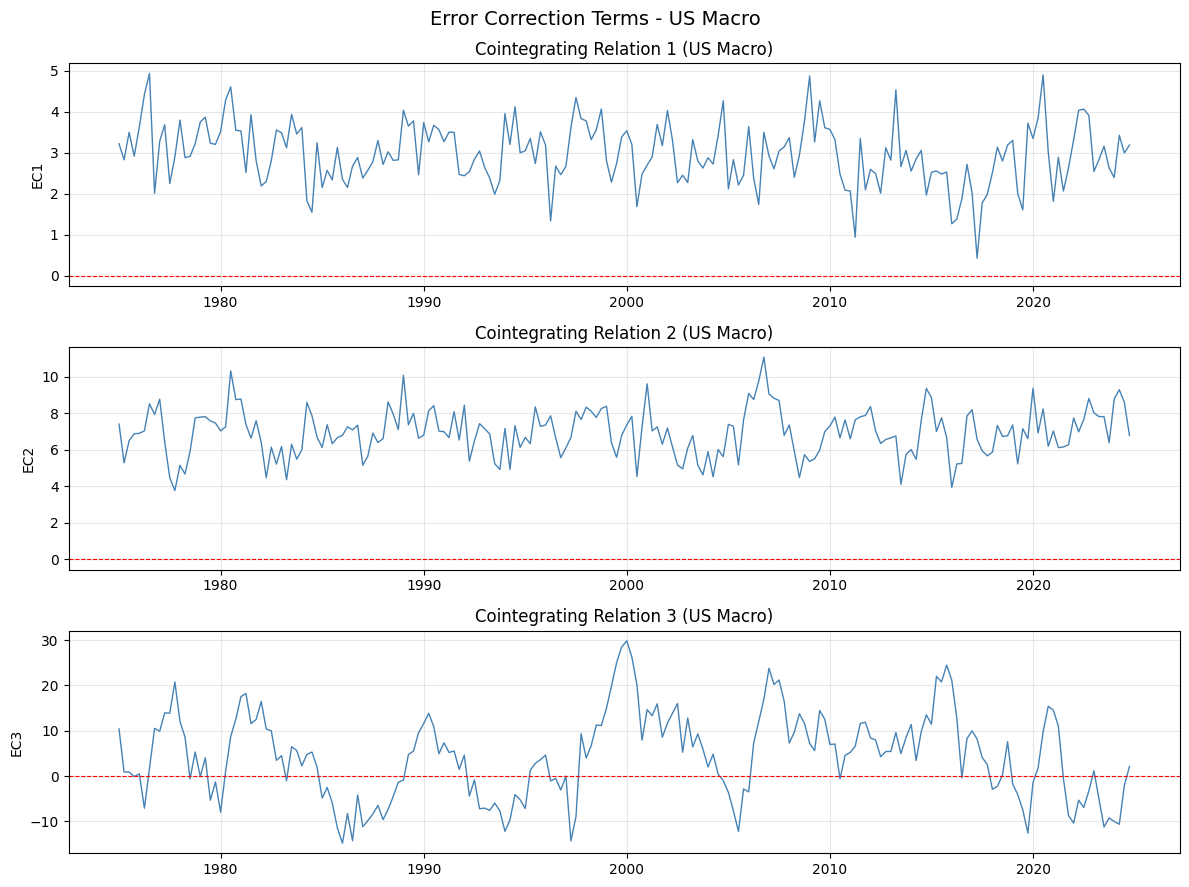

In [20]:
# Plot EC terms for US data
us_beta_vars = us_vecm_results.beta[:len(us_names), :]
us_ec_terms = us_endog @ us_beta_vars

fig, axes = plt.subplots(us_vecm_results.coint_rank, 1,
                         figsize=(12, 3 * us_vecm_results.coint_rank), squeeze=False)
fig.suptitle("Error Correction Terms - US Macro", fontsize=14)

us_dates = pd.to_datetime(us_df["date"])
for j in range(us_vecm_results.coint_rank):
    ax = axes[j, 0]
    ax.plot(us_dates, us_ec_terms[:, j], color="steelblue", linewidth=1.0)
    ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
    ax.set_ylabel(f"EC{j+1}")
    ax.set_title(f"Cointegrating Relation {j+1} (US Macro)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Pi matrix
us_pi = us_vecm_results.pi
print("Long-run matrix Pi = alpha * beta' (US Macro):")
print(pd.DataFrame(us_pi, index=us_names, columns=us_names).round(4))
print(f"\nRank of Pi: {us_vecm_results.coint_rank}")
print(f"Common stochastic trends: {len(us_names) - us_vecm_results.coint_rank}")

Long-run matrix Pi = alpha * beta' (US Macro):
                 gdp  inflation  fed_funds  unemployment
gdp          -0.4406    -0.0634    -0.0824        0.0312
inflation     0.1448    -0.4648     0.0124        0.0992
fed_funds     0.1680     0.1970    -0.1700        0.0929
unemployment -0.1443    -0.0053     0.0807       -0.0679

Rank of Pi: 3
Common stochastic trends: 1


In [22]:
# Step 6: Save results to outputs/johansen_results.json
outputs_dir = os.path.join("..", "outputs")
os.makedirs(outputs_dir, exist_ok=True)

johansen_output = {
    "dataset": "us_macro_quarterly.csv",
    "variables": us_names,
    "lags": 4,
    "deterministic": "ci",
    "nobs": int(us_endog.shape[0]),
    "trace_test": {
        "rank": int(us_johansen.rank_trace),
        "statistics": us_johansen.trace_stat.tolist(),
        "critical_values_95": [cv[1] for cv in us_johansen.trace_crit]
    },
    "max_eigenvalue_test": {
        "rank": int(us_johansen.rank_maxeig),
        "statistics": us_johansen.max_eig_stat.tolist(),
        "critical_values_95": [cv[1] for cv in us_johansen.max_eig_crit]
    },
    "eigenvalues": us_johansen.eigenvalues.tolist(),
    "vecm_estimation": {
        "coint_rank": int(us_vecm_results.coint_rank),
        "alpha": us_vecm_results.alpha.tolist(),
        "beta": us_vecm_results.beta.tolist(),
        "pi": us_vecm_results.pi.tolist()
    }
}

johansen_path = os.path.join(outputs_dir, "johansen_results.json")
with open(johansen_path, "w") as f:
    json.dump(johansen_output, f, indent=2)

print(f"Johansen results saved to {johansen_path}")
print(f"\nSummary:")
print(f"  Trace rank: {johansen_output['trace_test']['rank']}")
print(f"  Max-eig rank: {johansen_output['max_eigenvalue_test']['rank']}")
print(f"  VECM coint rank: {johansen_output['vecm_estimation']['coint_rank']}")

Johansen results saved to ../outputs/johansen_results.json

Summary:
  Trace rank: 3
  Max-eig rank: 3
  VECM coint rank: 3


---

## Exercise 2: Deterministic specification comparison (SOLUTION)

Compare Johansen test results on the Canadian data with:
- `deterministic="nc"` (no constant)
- `deterministic="ci"` (constant inside ECM)
- `deterministic="co"` (constant outside ECM)

In [23]:
# Compare deterministic specifications
print("Effect of Deterministic Specification on Johansen Test")
print("=" * 70)
print(f"{'Specification':>20s}  {'Trace rank':>12s}  {'Max-eig rank':>14s}  {'Eigenvalues':>30s}")
print("-" * 70)

det_results = {}
for det in ["nc", "ci", "co"]:
    v = VECM(lags=2, deterministic=det)
    j = v.johansen_test(endog)
    det_results[det] = j
    evs = ", ".join([f"{e:.4f}" for e in j.eigenvalues])
    print(f"{det:>20s}  {j.rank_trace:>12d}  {j.rank_maxeig:>14d}  {evs:>30s}")

Effect of Deterministic Specification on Johansen Test
       Specification    Trace rank    Max-eig rank                     Eigenvalues
----------------------------------------------------------------------
                  nc             0               0  0.1050, 0.0392, 0.0309, 0.0000
                  ci             0               0  0.1050, 0.0392, 0.0309, 0.0000
                  co             0               0  0.1060, 0.0438, 0.0309, 0.0000


In [24]:
# Detailed comparison for each specification
for det in ["nc", "ci", "co"]:
    j = det_results[det]
    print(f"\n{'='*50}")
    print(f"Deterministic = '{det}'")
    print(f"{'='*50}")
    print(f"{'r':>4s}  {'Trace':>10s}  {'95% CV':>10s}  {'Max-Eig':>10s}  {'95% CV':>10s}")
    for r in range(K):
        ts = j.trace_stat[r]
        tc = j.trace_crit[r][1]
        ms = j.max_eig_stat[r]
        mc = j.max_eig_crit[r][1]
        print(f"{r:>4d}  {ts:>10.4f}  {tc:>10.4f}  {ms:>10.4f}  {mc:>10.4f}")
    print(f"  => Trace rank = {j.rank_trace}, Max-eig rank = {j.rank_maxeig}")


Deterministic = 'nc'
   r       Trace      95% CV     Max-Eig      95% CV
   0     14.9529     47.2100      9.0981     27.0700
   1      5.8548     29.6800      3.2821     20.9700
   2      2.5727     15.4100      2.5727     14.0700
   3      0.0000      3.7600      0.0000      3.7600
  => Trace rank = 0, Max-eig rank = 0

Deterministic = 'ci'
   r       Trace      95% CV     Max-Eig      95% CV
   0     14.9529     53.1200      9.0981     28.1400
   1      5.8548     34.9100      3.2821     22.0000
   2      2.5727     19.9600      2.5727     15.6700
   3     -0.0000      9.2400     -0.0000      9.2400
  => Trace rank = 0, Max-eig rank = 0

Deterministic = 'co'
   r       Trace      95% CV     Max-Eig      95% CV
   0     15.4321     48.2800      9.1837     27.1400
   1      6.2485     31.5200      3.6766     21.0700
   2      2.5719     17.9500      2.5719     14.9000
   3     -0.0000      8.1800     -0.0000      8.1800
  => Trace rank = 0, Max-eig rank = 0


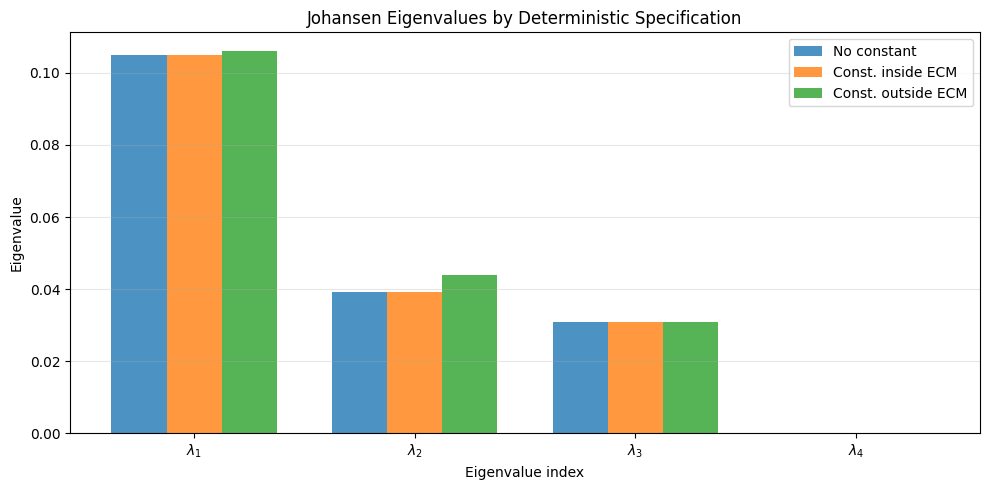


--- Conclusion ---
The deterministic specification affects the critical values and thus
the inferred cointegration rank. 'ci' (restricted constant) is the
most common choice for macroeconomic data with non-zero means.
'nc' may over-reject if the data has a non-zero mean.
'co' allows for a linear trend in the cointegrating relations.


In [25]:
# Visual comparison of eigenvalues across specifications
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(1, K + 1)
width = 0.25

for i, (det, label) in enumerate([("nc", "No constant"), ("ci", "Const. inside ECM"),
                                    ("co", "Const. outside ECM")]):
    ax.bar(x + i * width, det_results[det].eigenvalues, width, label=label, alpha=0.8)

ax.set_xlabel("Eigenvalue index")
ax.set_ylabel("Eigenvalue")
ax.set_title("Johansen Eigenvalues by Deterministic Specification")
ax.set_xticks(x + width)
ax.set_xticklabels([f"$\\lambda_{i}$" for i in range(1, K + 1)])
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("\n--- Conclusion ---")
print("The deterministic specification affects the critical values and thus")
print("the inferred cointegration rank. 'ci' (restricted constant) is the")
print("most common choice for macroeconomic data with non-zero means.")
print("'nc' may over-reject if the data has a non-zero mean.")
print("'co' allows for a linear trend in the cointegrating relations.")

---

## Summary

In this solution notebook we:

1. Performed full Johansen cointegration analysis on Canadian data
2. **Exercise 1**: Applied cointegration analysis to US macro data with complete interpretation
3. **Exercise 2**: Compared deterministic specifications and their effect on rank inference
4. Saved all outputs:
   - `outputs/johansen_results.json` - Full Johansen test results and VECM estimates